In [1]:
import os
import torch
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
from scipy.stats import skew
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.utils import resample
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.inspection import permutation_importance
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score,precision_score, roc_auc_score
from sklearn.decomposition import PCA
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
root_dir = 'smaller_dataset.csv'
df = pd.read_csv(root_dir)
df["Weight"] = df["Total Fwd Packet"] * df["Total Bwd packets"]

In [ ]:
categorical_columns = ["Src IP", 'Dst IP', "Src Port", "Dst Port", "Protocol"]  

for col in categorical_columns:
    df[col] = df[col].astype('category')

for col in ['Src IP', 'Dst IP', 'Src Port', 'Dst Port']:
    df[col + '_freq'] = df[col].map(df[col].value_counts())

df = pd.get_dummies(df, columns=['Protocol'], prefix='Proto')

In [4]:
df.shape

(439447, 92)

In [5]:
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Attack_Type,Weight,Src IP_freq,Dst IP_freq,Src Port_freq,Dst Port_freq,Proto_0,Proto_6,Proto_17
0,192.168.137.144-192.168.137.240-49153-13217-6,192.168.137.144,49153,192.168.137.240,13217,05/08/2022 10:53:38 AM,18188538,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.274898,4547134.5,2.655540e+06,6473349.0,672643.0,0.0,0.0,0.0,0.0,0.0,13184858.0,4.394953e+06,3.230926e+06,6473349.0,672643.0,0,0,0,0,24,80,0.054980,0.219919,0.0,0.0,0.000000,0.000000,0.000000,0,4,1,0,1,0,0,0,4.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,5.838632e+06,755017.935929,6473349.0,5003680.0,NeedManualLabel,DoS_DoS SYN Flood,4,1361,1363,1417,1,False,True,False
1,192.168.137.65-192.168.137.171-7661-6668-6,192.168.137.65,7661,192.168.137.171,6668,26/10/2022 11:53:56 AM,99736150,2,0,2920.0,0.0,1460.0,1460.0,1460.0,0.0,0.0,0.0,0.0,0.0,29.277248,0.020053,99736150.0,0.000000e+00,99736150.0,99736150.0,99736150.0,99736150.0,0.0,99736150.0,99736150.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,0,0,40,0,0.020053,0.000000,1460.0,1460.0,1460.000000,0.000000,0.000000,0,0,0,0,2,0,0,0,0.0,2190.0,1460.0,0.0,0,0,0,0,0,0,2,2920,0,0,512,0,1,20,0.0,0.0,0.0,0.0,9.973615e+07,0.000000,99736150.0,99736150.0,NeedManualLabel,DDoS_DDoS ACK Fragmentation,0,658,116,1,9306,False,True,False
2,192.168.137.12-192.168.137.235-15376-8008-6,192.168.137.12,15376,192.168.137.235,8008,26/10/2022 03:46:03 PM,88834040,2,0,2920.0,0.0,1460.0,1460.0,1460.0,0.0,0.0,0.0,0.0,0.0,32.870283,0.022514,88834040.0,0.000000e+00,88834040.0,88834040.0,88834040.0,88834040.0,0.0,88834040.0,88834040.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,0,0,40,0,0.022514,0.000000,1460.0,1460.0,1460.000000,0.000000,0.000000,0,0,0,0,2,0,0,0,0.0,2190.0,1460.0,0.0,0,0,0,0,0,0,2,2920,0,0,512,0,1,20,0.0,0.0,0.0,0.0,8.883404e+07,0.000000,88834040.0,88834040.0,NeedManualLabel,DDoS_DDoS ACK Fragmentation,0,283,777,2,960,False,True,False
3,192.168.137.12-192.168.137.206-21499-55442-6,192.168.137.12,21499,192.168.137.206,55442,26/10/2022 04:50:41 PM,17797062,1,1,1460.0,0.0,1460.0,1460.0,1460.0,0.0,0.0,0.0,0.0,0.0,82.036012,0.112378,17797062.0,0.000000e+00,17797062.0,17797062.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,0,0,20,20,0.056189,0.056189,0.0,1460.0,973.333333,842.931393,710533.333333,0,0,1,0,1,0,0,0,1.0,1460.0,1460.0,0.0,0,0,0,0,0,0,1,1460,1,0,512,0,0,20,0.0,0.0,0.0,0.0,1.779706e+07,0.000000,17797062.0,17797062.0,NeedManualLabel,DDoS_DDoS ACK Fragmentation,1,283,131,1,702,False,True,False
4,192.168.137.225-192.168.137.132-38616-8080-6,192.168.137.225,38616,192.168.137.132,8080,14/09/2022 11:10:19 AM,294063,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,6.801264,294063.0,0.000000e+00,294063.0,294063.0,0

In [6]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'],  format='%d/%m/%Y %I:%M:%S %p')

In [7]:
attacks_to_remove = [
    "spoofing_ARP Spoofing",
    "spoofing_DNS Spoofing",
    "sqlinjection",
    "XSS",
    "Benign&Bruteforce_BruteForce",
    "Uploading_Attack"
]

df = df[~df["Attack_Type"].isin(attacks_to_remove)]

In [8]:
columns_to_drop = ["Flow IAT Std",
                   "Bwd Segment Size Avg",
                   "Subflow Fwd Packets",
    'Flow Duration',
    'Subflow Bwd Packets',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Flow Packets/s',
    'Flow IAT Min',
    'Flow IAT Max',
    'Bwd IAT Max',
    'Bwd IAT Min',
    'Fwd Header Length',
    'ACK Flag Count',
    'Packet Length Std',
    "Fwd IAT Max",
    "Idle Max",
    "Idle Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    'Average Packet Size',
    'Fwd Segment Size Avg',
    'Fwd IAT Max',
    'Bwd Header Length',
    'Packet Length Mean',
    'CWR Flag Count',
    'Average Packet Size',
    "Flow IAT Mean",
    "Active Max",
    "Bwd Bytes/Bulk Avg",
    'Fwd IAT Mean',
    'Active Mean',
    'Active Std',
    "Fwd Act Data Pkts"
]

df = df.drop(columns=columns_to_drop)
df = df.drop(columns="Label")

def create_anomaly_label(row):
    if row['Attack_Type'] == 'Benign&Bruteforce_benign':
        return 'Normal'
    else:
        return 'Attack'

df['Anomaly_Label'] = df.apply(create_anomaly_label, axis=1)

null_columns = df.isnull().sum()
null_columns = null_columns[null_columns > 0]


inf_columns = df.columns[(df == np.inf).any() | (df == -np.inf).any()]

df = df.dropna()

df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]

df.replace([np.inf, -np.inf], np.nan, inplace=True)




In [ ]:
def preprocess_data(df):
    X = df.select_dtypes(include=['number', 'bool'])
    X_datetime = df.select_dtypes(include=['datetime64'])
    y = df['Anomaly_Label']  # Target variable
    y = (y == "Attack").astype(int)  # Attack = 1, Normal = 0

    # Convert datetime to Unix timestamps (seconds)
    for col in X_datetime.columns:
        X_datetime[col] = pd.to_datetime(X_datetime[col]).astype('int64') // 10**9

    # Scale numerical and boolean features
    scaler_numerical = StandardScaler()
    X_scaled_num = scaler_numerical.fit_transform(X)

    # Scale datetime features
    scaler_datetime = StandardScaler()
    X_scaled_datetime = scaler_datetime.fit_transform(X_datetime)


    X_scaled= np.concatenate([X_scaled_num, X_scaled_datetime], axis=1)
    
    pca = PCA(n_components=0.95)  # Retain 95% of variance
   
    print("Had ", X_scaled.shape[1] ,"features")


    X_scaled = pca.fit_transform(X_scaled)


    print("Components after reduction: ", pca.n_components_)  # number of components after reduction

    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA - Explained Variance vs Components')
    plt.grid(True)
    plt.show()
    
    return X_scaled, y

Had  53 features
Components after reduction:  30


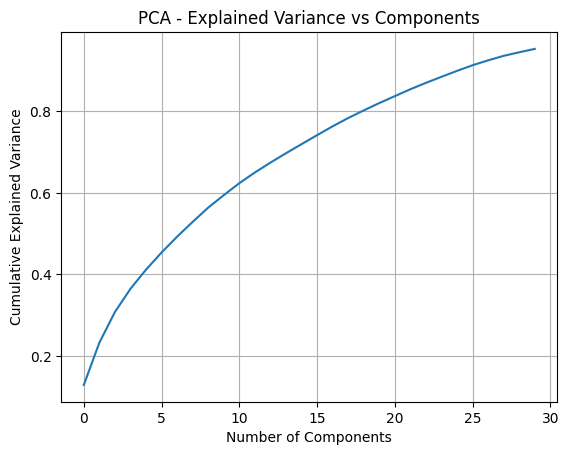

In [26]:
X_scaled,y = preprocess_data(df)

In [ ]:
import torch
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, activation=nn.ReLU(), dropout_rate=0.0, 
                 sequence_length=1, num_layers=1, bidirectional=False):
        super(LSTMAutoencoder, self).__init__()

        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.bottleneck_dim = hidden_dims[-1]
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.directions = 2 if bidirectional else 1
        self.activation = activation

      
        self.encoder_layers = nn.ModuleList()
        prev_dim = input_dim
        for h_dim in hidden_dims:
            self.encoder_layers.append(nn.LSTM(
                input_size=prev_dim,
                hidden_size=h_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=bidirectional
            ))
            prev_dim = h_dim * self.directions

     
        self.decoder_layers = nn.ModuleList()
        reversed_dims = list(reversed(hidden_dims))
        prev_dim = reversed_dims[0] * self.directions 

  
        for i in range(len(reversed_dims) - 1):
            next_dim = reversed_dims[i+1]
            self.decoder_layers.append(nn.LSTM(
                input_size=prev_dim,
                hidden_size=next_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=bidirectional
            ))
            prev_dim = next_dim * self.directions

        # Final output layer
        self.output_layer = nn.Linear(hidden_dims[0] * self.directions, input_dim)

        # Dropout layer
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

    def forward(self, x):
       
        original_shape = x.shape
        if len(x.shape) == 2:
            x = x.unsqueeze(1)  # [batch_size, 1, input_dim]

        batch_size = x.size(0)
        seq_len = x.size(1)

       
        current_input = x
        for i, encoder in enumerate(self.encoder_layers):
            outputs, (hidden, cell) = encoder(current_input)
            current_input = outputs
            
            
            if self.activation is not None:
                current_input = self.activation(current_input)

           
            if self.dropout is not None and i < len(self.encoder_layers) - 1:
                current_input = self.dropout(current_input)

        
        encoded = outputs[:, -1, :]

      
        decoder_input = encoded.unsqueeze(1).repeat(1, seq_len, 1)

    
        current_input = decoder_input
        for i, decoder in enumerate(self.decoder_layers):
            outputs, _ = decoder(current_input)
            current_input = outputs
            
  
            if self.activation is not None and i < len(self.decoder_layers) - 1:
                current_input = self.activation(current_input)

           
            if self.dropout is not None and i < len(self.decoder_layers) - 1:
                current_input = self.dropout(current_input)

       
        reconstructed = self.output_layer(current_input)

       
        if len(original_shape) == 2:
            reconstructed = reconstructed.squeeze(1)

        return reconstructed

In [ ]:
def train_and_evaluate(model, train_loader, val_loader, X_test_tensor, y_val, y_test, 
                      epochs, optimizer, criterion, device, 
                      early_stopping=True, patience=5):
    
    model.to(device)
    
   
    model.train()
    history = {'loss': []}
    best_loss = float('inf')
    trigger_times = 0
    
    for epoch in range(epochs):
        epoch_loss = 0
        for batch in train_loader:
            inputs = batch[0].to(device)
            
       
            if isinstance(model, LSTMAutoencoder):
                outputs = model(inputs)  
            else:
                outputs = model(inputs)  
                
            loss = criterion(outputs, inputs)
            
      
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        history['loss'].append(avg_loss)
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
        
       
        if epoch == 0 or (epoch+1) % 5 == 0:
            with torch.no_grad():
                
                sample_inputs = next(iter(train_loader))[0].to(device)
                sample_outputs = model(sample_inputs)
                
              
                print("Sample original values:", sample_inputs[0][:5].cpu().numpy())
                print("Sample reconstructed values:", sample_outputs[0][:5].cpu().numpy())
                print("Sample reconstruction error:", torch.mean((sample_inputs[0] - sample_outputs[0])**2).item())

    
        if early_stopping:
            if avg_loss < best_loss:
                best_loss = avg_loss
                best_model_state = model.state_dict()
                trigger_times = 0
            else:
                trigger_times += 1
                if trigger_times >= patience:
                    print(f"Early stopping triggered after {epoch+1} epochs")
                    break


    if early_stopping and 'best_model_state' in locals():
        model.load_state_dict(best_model_state)

    model.eval()
    val_errors = []
    
    with torch.no_grad():
        for batch in val_loader:
            inputs = batch[0].to(device)
            reconstructions = model(inputs)
          
            batch_errors = torch.mean((inputs - reconstructions) ** 2, dim=1).cpu().numpy()
            val_errors.extend(batch_errors)

   
    print(f"Validation errors - min: {np.min(val_errors):.6f}, max: {np.max(val_errors):.6f}, mean: {np.mean(val_errors):.6f}")
    
    
    best_f1 = 0
    best_threshold = 0
    
    for percentile in range(80, 100):
        threshold = np.percentile(val_errors, percentile)
        y_pred = (np.array(val_errors) > threshold).astype(int)
        f1 = f1_score(y_val, y_pred)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    print(f"Optimal threshold: {best_threshold:.6f}, F1 score on validation set: {best_f1:.4f}")

   
    model.eval()
    with torch.no_grad():
        X_test_device = X_test_tensor.to(device)
        reconstructions = model(X_test_device)

        reconstruction_error = torch.mean((X_test_device - reconstructions) ** 2, dim=1).cpu().numpy()
    
    
    print(f"Test errors - min: {np.min(reconstruction_error):.6f}, max: {np.max(reconstruction_error):.6f}, mean: {np.mean(reconstruction_error):.6f}")
    

    y_test_np = np.array(y_test)
    y_pred = (reconstruction_error > best_threshold).astype(int)
    
    # Metrics
    results = {
        'threshold': best_threshold,
        'val_f1': best_f1,
        'accuracy': accuracy_score(y_test_np, y_pred),
        'f1': f1_score(y_test_np, y_pred),
        'precision': precision_score(y_test_np, y_pred),
        'recall': recall_score(y_test_np, y_pred),
        'roc_auc': roc_auc_score(y_test_np, reconstruction_error),
        'confusion_matrix': confusion_matrix(y_test_np, y_pred),
        'reconstruction_error': reconstruction_error
    }
    
    print("\nTest Set Metrics:")
    print(f"Accuracy: {results['accuracy']:.4f}")
    print(f"F1 Score: {results['f1']:.4f}")
    print(f"Precision: {results['precision']:.4f}")
    print(f"Recall: {results['recall']:.4f}")
    print(f"ROC-AUC: {results['roc_auc']:.4f}")
    
    return model, history, results

In [ ]:
def run_lstm_hyperparameter_grid(X_train_tensor, X_val_tensor, X_test_tensor, y_val, y_test, input_dim, 
                               batch_sizes, architectures, learning_rates, epochs_list, 
                               dropout_rates, activation_functions, sequence_lengths=[1],
                               bidirectional_options=[False], num_layers_options=[1],
                               early_stopping=True, patience=5):
    
    results_list = []
    best_f1 = 0
    best_config = None
    best_model = None
    
    total_combinations = (len(batch_sizes) * len(architectures) * len(learning_rates) * 
                         len(epochs_list) * len(dropout_rates) * len(activation_functions) *
                         len(sequence_lengths) * len(bidirectional_options) * len(num_layers_options))
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    print(f"Running LSTM grid search with {total_combinations} combinations")
    combination_counter = 0
    
    for batch_size in batch_sizes:
        
        train_dataset = TensorDataset(X_train_tensor)
        val_dataset = TensorDataset(X_val_tensor)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        for architecture in architectures:
            for dropout_rate in dropout_rates:
                for activation_name, activation_fn in activation_functions.items():
                    for lr in learning_rates:
                        for epochs in epochs_list:
                            for sequence_length in sequence_lengths:
                                for bidirectional in bidirectional_options:
                                    for num_layers in num_layers_options:
                                    
                                        combination_counter += 1
                                        print(f"\nCombination {combination_counter}/{total_combinations}")
                                        print(f"Testing: batch_size={batch_size}, architecture={architecture}, "
                                            f"activation={activation_name}, lr={lr}, epochs={epochs}, "
                                            f"dropout={dropout_rate}, sequence_length={sequence_length}, "
                                            f"bidirectional={bidirectional}, num_layers={num_layers}")
                                        
                                        
                                        model = LSTMAutoencoder(
                                            input_dim=input_dim,
                                            hidden_dims=architecture,
                                            activation=activation_fn,
                                            dropout_rate=dropout_rate,
                                            sequence_length=sequence_length,
                                            bidirectional=bidirectional,
                                            num_layers=num_layers
                                        ).to(device)
                                        
                                       
                                        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                                        criterion = nn.MSELoss()
                                        
                                      
                                        trained_model, history, eval_results = train_and_evaluate(
                                            model=model,
                                            train_loader=train_loader,
                                            val_loader=val_loader,
                                            X_test_tensor=X_test_tensor,
                                            y_val=y_val,
                                            y_test=y_test,
                                            epochs=epochs,
                                            optimizer=optimizer,
                                            criterion=criterion,
                                            device=device,
                                            early_stopping=early_stopping,
                                            patience=patience
                                        )

                                        
                                        config = {
                                            'batch_size': batch_size,
                                            'architecture': architecture,
                                            'activation': activation_name,
                                            'learning_rate': lr,
                                            'epochs': epochs,
                                            'dropout_rate': dropout_rate,
                                            'sequence_length': sequence_length,
                                            'bidirectional': bidirectional,
                                            'num_layers': num_layers,
                                            'early_stopping': early_stopping,
                                            'patience': patience
                                        }
                                        
                                        result = {**config, **{k: v for k, v in eval_results.items() 
                                                            if k not in ['confusion_matrix', 'reconstruction_error']}}
                                        results_list.append(result)
                                        
                                        
                                        if eval_results['f1'] > best_f1:
                                            best_f1 = eval_results['f1']
                                            best_config = config
                                            best_model = trained_model
                                        
                                       
                                        print(f"  F1: {eval_results['f1']:.4f}, "
                                            f"Precision: {eval_results['precision']:.4f}, "
                                            f"Recall: {eval_results['recall']:.4f}, "
                                            f"AUC: {eval_results['roc_auc']:.4f}")
                                        print("-" * 50)
    

    results_df = pd.DataFrame(results_list)
    
    return results_df, best_model, best_config

In [ ]:
def run_lstm_full_hyperparameter_search(name, df):
    """
    Run a comprehensive hyperparameter search for LSTM-based autoencoder
    
    Args:
        name: Prefix for saving results
        df: DataFrame with data (must include 'Anomaly_Label' column)
        
    Returns:
        best_model: The best performing model
        best_config: Configuration of the best model
        results_df: DataFrame with all results
    """

    batch_sizes = [32]
    architectures = [
        [64, 32, 16],
        [32, 16, 8],
        [16,8]
    ]
    learning_rates = [1e-3]
    epochs_list = [10, 50]
    dropout_rates = [0.1]
    activation_functions = {
        'ReLU': nn.ReLU(),
        'Tanh': nn.Tanh()
    }
    sequence_lengths = [5,10] 
    bidirectional_options = [False, True]  
    num_layers_options = [1]  
    
  
    early_stopping = True
    patience = 5

    X_scaled, y = preprocess_data(df)
    

    print(f"Data shape: {X_scaled.shape}")
    print(f"Feature stats - min: {np.min(X_scaled):.4f}, max: {np.max(X_scaled):.4f}, mean: {np.mean(X_scaled):.4f}, std: {np.std(X_scaled):.4f}")
    print(f"Label distribution: {np.bincount(y)}")
    
 
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y)
    
 
    X_train_full, X_val, y_train_full, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.143, random_state=42, stratify=y_train_val) 

   
    X_train = X_train_full[y_train_full == 0]
    input_dim = X_train.shape[1]
    

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    

    print(f"Training tensor shape: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}")
    print(f"Validation tensor shape: {X_val_tensor.shape}, dtype: {X_val_tensor.dtype}")
    print(f"Test tensor shape: {X_test_tensor.shape}, dtype: {X_test_tensor.dtype}")
    

    y_val = y_val.values if hasattr(y_val, 'values') else y_val
    y_test = y_test.values if hasattr(y_test, 'values') else y_test
    
    results_df, best_model, best_config = run_lstm_hyperparameter_grid(
        X_train_tensor, X_val_tensor, X_test_tensor, y_val, y_test, input_dim,
        batch_sizes, architectures, learning_rates, epochs_list,
        dropout_rates, activation_functions, sequence_lengths,
        bidirectional_options, num_layers_options,
        early_stopping=early_stopping, patience=patience
    )
    
   
    results_df.to_csv(f'{name}_lstm.csv', index=False)
    
    print("\nFull LSTM Grid Search Results Summary:")
    print(f"Number of configurations tested: {len(results_df)}")
    print("\nBest Configurations by F1 Score:")
    print(results_df.sort_values('f1', ascending=False).head())
    
    print("\nBest Configuration:")
    print(best_config)
    
    return best_model, best_config, results_df

In [30]:
run_lstm_full_hyperparameter_search("lstm_pca", df)

Data shape: (438915, 30)
Feature stats - min: -298.5718, max: 586.1354, mean: -0.0000, std: 1.2085
Label distribution: [398198  40717]
Training tensor shape: torch.Size([238878, 30]), dtype: torch.float32
Validation tensor shape: torch.Size([43936, 30]), dtype: torch.float32
Test tensor shape: torch.Size([131675, 30]), dtype: torch.float32
Using device: cuda
Running LSTM grid search with 48 combinations

Combination 1/48
Testing: batch_size=32, architecture=[64, 32, 16], activation=ReLU, lr=0.001, epochs=10, dropout=0.1, sequence_length=5, bidirectional=False, num_layers=1
Epoch 1/10, Loss: 0.710653
Sample original values: [-1.3096442   0.0203101   0.2506741  -0.38429335 -0.60427785]
Sample reconstructed values: [-1.636043   -0.33163112  0.20921864 -0.06249399 -0.08735012]
Sample reconstruction error: 0.056828055530786514
Epoch 2/10, Loss: 0.476564
Epoch 3/10, Loss: 0.399981
Epoch 4/10, Loss: 0.367173
Epoch 5/10, Loss: 0.340758
Sample original values: [-1.9933156  -0.6215535   0.346340

(LSTMAutoencoder(
   (activation): Tanh()
   (encoder_layers): ModuleList(
     (0): LSTM(30, 64, batch_first=True, bidirectional=True)
     (1): LSTM(128, 32, batch_first=True, bidirectional=True)
     (2): LSTM(64, 16, batch_first=True, bidirectional=True)
   )
   (decoder_layers): ModuleList(
     (0): LSTM(32, 32, batch_first=True, bidirectional=True)
     (1): LSTM(64, 64, batch_first=True, bidirectional=True)
   )
   (output_layer): Linear(in_features=128, out_features=30, bias=True)
   (dropout): Dropout(p=0.1, inplace=False)
 ),
 {'batch_size': 32,
  'architecture': [64, 32, 16],
  'activation': 'Tanh',
  'learning_rate': 0.001,
  'epochs': 50,
  'dropout_rate': 0.1,
  'sequence_length': 5,
  'bidirectional': True,
  'num_layers': 1,
  'early_stopping': True,
  'patience': 5},
     batch_size  architecture activation  learning_rate  epochs  dropout_rate  \
 0           32  [64, 32, 16]       ReLU          0.001      10           0.1   
 1           32  [64, 32, 16]       ReLU  